# 03 — Model Training & Evaluation

Train 4 models, Bootstrap Learning Curves, so sánh kết quả.

**Thứ tự chạy:** 01_eda → 02_processing → **03_modeling**

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

from src.model_trainer import ModelTrainer

## 1. Load Processed Data

Load 6 file `.npy` đã lưu ở notebook 02 — train / val / test.

| File | Vai trò |
|------|---------|
| `X_train`, `y_train` | Dạy model |
| `X_val`, `y_val` | Tune, early stopping, chọn model |
| `X_test`, `y_test` | Đánh giá cuối cùng — chỉ dùng 1 lần |


In [2]:
X_train = np.load('../data/X_train.npy')
X_val   = np.load('../data/X_val.npy')
X_test  = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_val   = np.load('../data/y_val.npy')
y_test  = np.load('../data/y_test.npy')

target_classes = ['Abnormal', 'Inconclusive', 'Normal']

n = len(X_train) + len(X_val) + len(X_test)
print(f'X_train : {X_train.shape}  ({len(X_train)/n*100:.0f}%)')
print(f'X_val   : {X_val.shape}   ({len(X_val)/n*100:.0f}%)')
print(f'X_test  : {X_test.shape}   ({len(X_test)/n*100:.0f}%)')


X_train : (44400, 12)  (80%)
X_val   : (5550, 12)   (10%)
X_test  : (5550, 12)   (10%)


## 2. Train 4 Models + Bootstrap Learning Curves

`ModelTrainer` train 4 models cùng lúc. Bootstrap curves dùng `X_val`
để đo performance tại mỗi epoch → thấy model hội tụ như thế nào.

In [3]:
trainer = ModelTrainer()
trainer.fit(
    X_train, y_train,
    X_test,  y_test,
    X_val=X_val, y_val=y_val,  # dùng val để track learning curve
    run_bootstrap = True,
    n_points      = 12,
    n_iters       = 3,
    run_cv        = True
)


Train: (44400, 12) | Val: (5550, 12) | Test: (5550, 12)

Training Logistic Regression... test_acc=0.3321  val_acc=0.3274  f1=0.3271  cv=0.3324±0.0040  (11.2s)
Training Decision Tree... test_acc=0.3310  val_acc=0.3514  f1=0.3196  cv=0.3386±0.0035  (12.2s)
Training Random Forest... test_acc=0.3420  val_acc=0.3393  f1=0.3306  cv=0.3399±0.0034  (27.6s)
Training Gradient Boosting... test_acc=0.3389  val_acc=0.3550  f1=0.3383  cv=0.3473±0.0065  (567.7s)

 Best: Random Forest (test_acc=0.3420)


## 3. Kết quả tổng hợp

In [4]:
trainer.summary()

                     Test Acc  Test F1  Val Acc  Val F1  CV Mean  CV Std  Time (s)
Model                                                                             
Random Forest          0.3420   0.3306   0.3393  0.3262   0.3399  0.0034      11.1
Gradient Boosting      0.3389   0.3383   0.3550  0.3543   0.3473  0.0065     294.7
Logistic Regression    0.3321   0.3271   0.3274  0.3225   0.3324  0.0040      10.4
Decision Tree          0.3310   0.3196   0.3514  0.3418   0.3386  0.0035      10.5


,Test Acc,Test F1,Val Acc,Val F1,CV Mean,CV Std,Time (s)
Model,,,,,,,
Random Forest,0.3420,0.3306,0.3393,0.3262,0.3399,0.0034,11.1
Gradient Boosting,0.3389,0.3383,0.3550,0.3543,0.3473,0.0065,294.7
Logistic Regression,0.3321,0.3271,0.3274,0.3225,0.3324,0.0040,10.4
Decision Tree,0.3310,0.3196,0.3514,0.3418,0.3386,0.0035,10.5


## 4. Bootstrap Learning Curves

**Đọc biểu đồ:**
- Trục X = % training data đã dùng (= 'epoch')
- Đường = accuracy/F1 trung bình qua 3 bootstrap runs
- Vùng bóng = mean ± std → hẹp = model ổn định, rộng = high variance
- Đường đỏ đứt = random baseline 33.3%

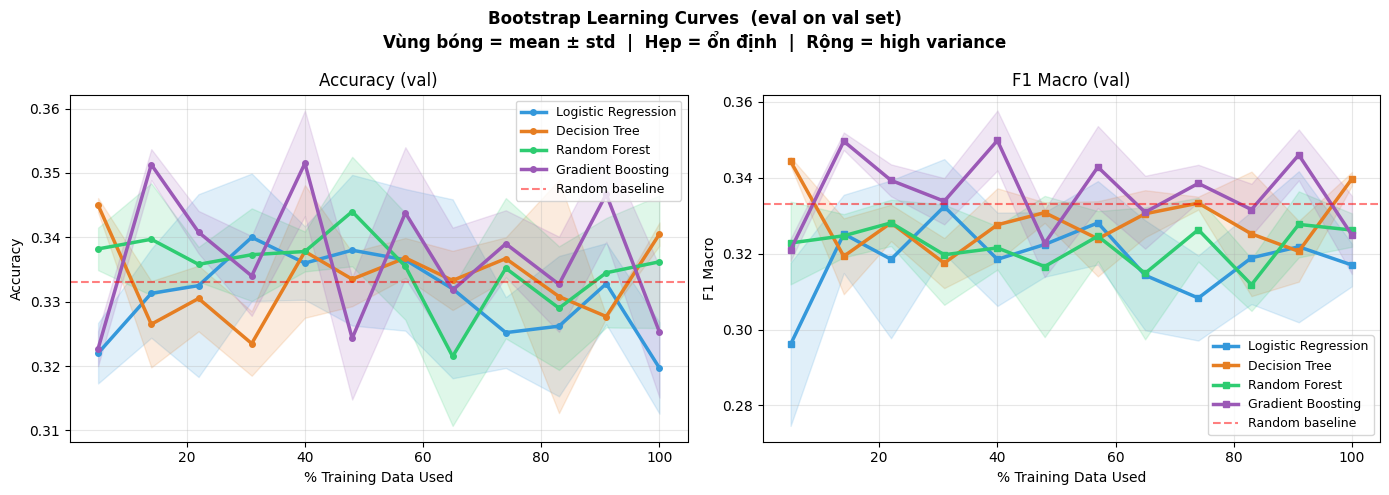

In [5]:
trainer.plot_bootstrap_curves()

## 5. So sánh Models

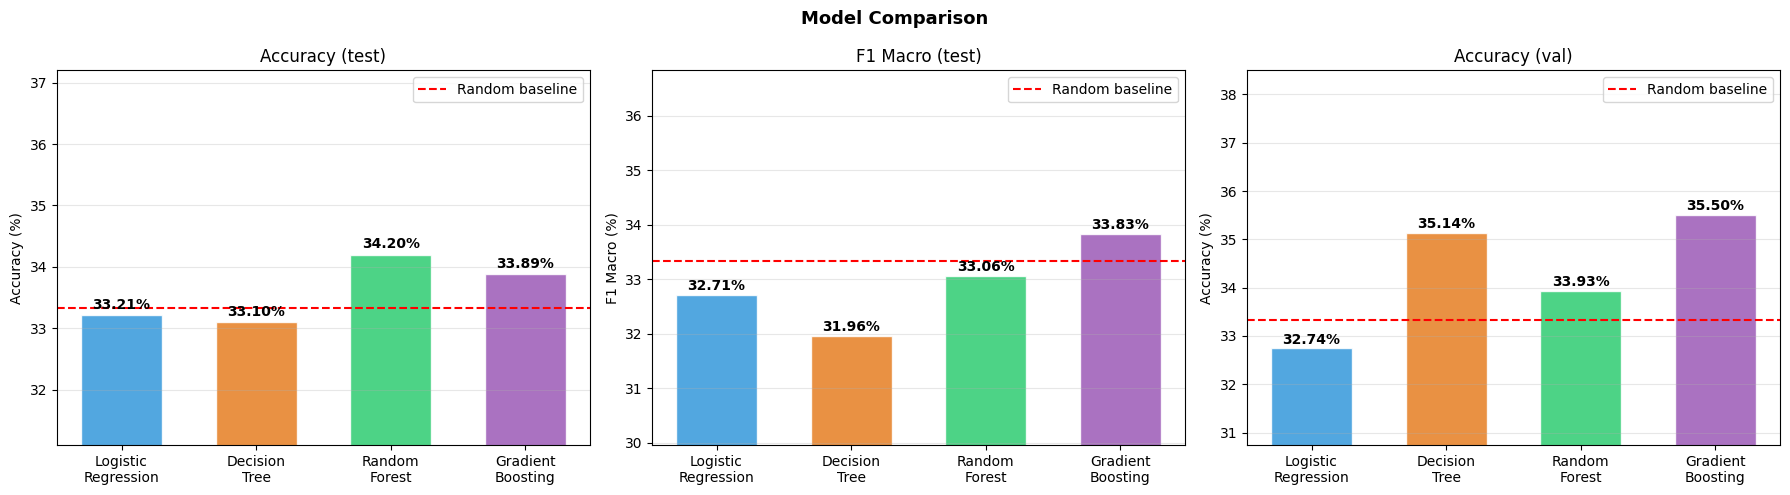

In [6]:
trainer.plot_comparison()

## 6. Confusion Matrices

**Đọc confusion matrix:**
- Diagonal (trái trên → phải dưới) = dự đoán **ĐÚNG**
- Off-diagonal = dự đoán **SAI** (model nhầm class nào sang class nào)

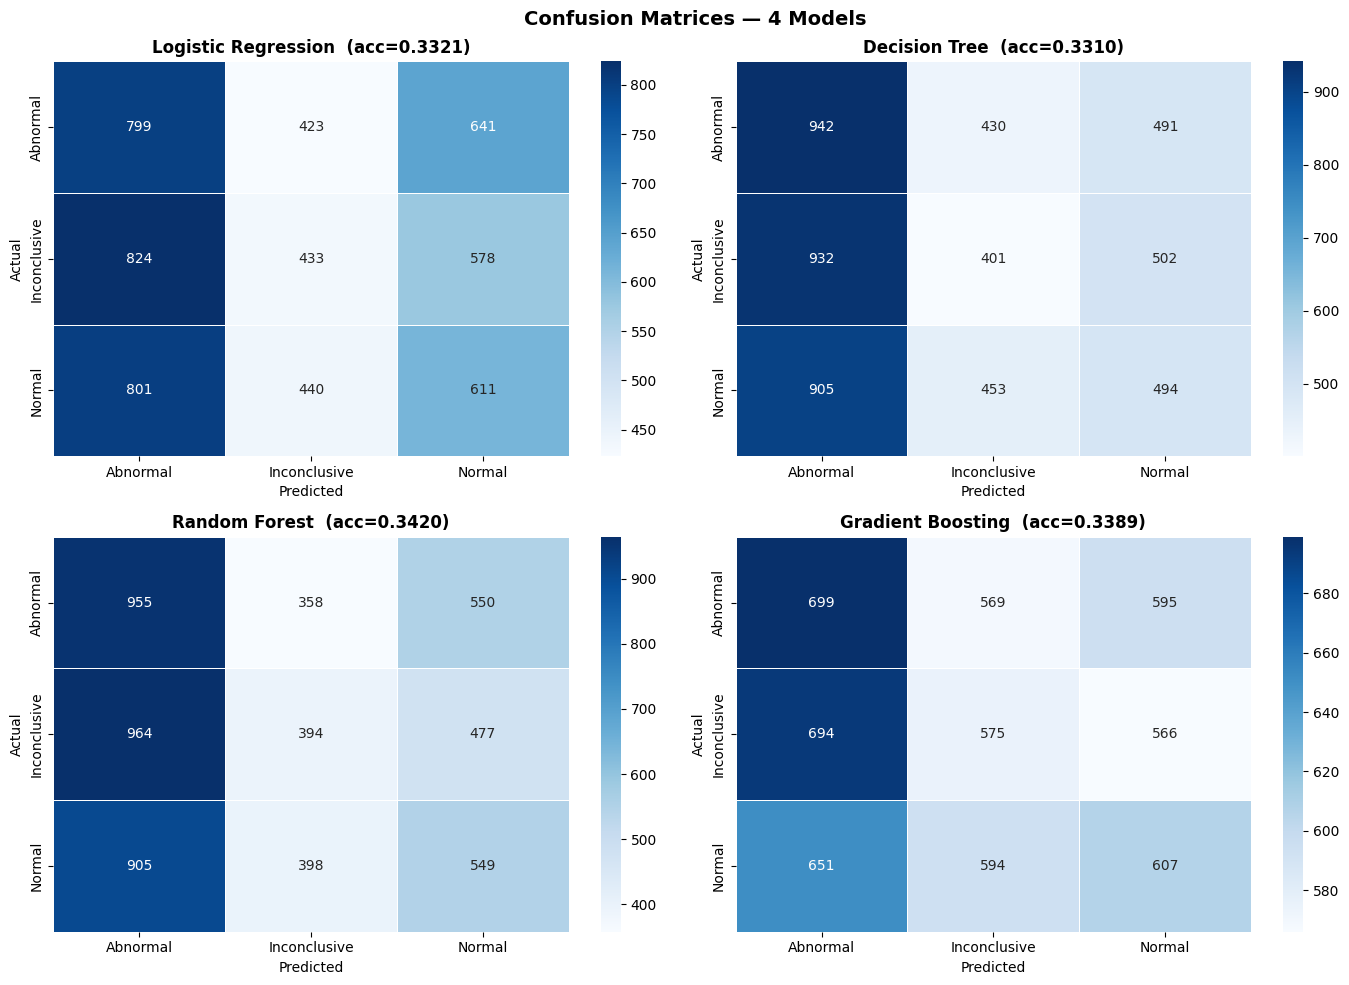

In [7]:
# Vẽ confusion matrix cho từng model
n = len(trainer.results)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — 4 Models', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, res) in enumerate(trainer.results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=target_classes, yticklabels=target_classes,
                linewidths=0.5)
    axes[i].set_title(f'{name}  (acc={res["accuracy"]:.4f})', fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 7. Classification Report — Best Model

**Metrics:**
- `Precision`: trong số dự đoán là X, bao nhiêu % thực sự là X?
- `Recall`: trong số thực sự là X, model tìm được bao nhiêu %?
- `F1-score`: trung bình điều hòa của Precision và Recall
- `Support`: số mẫu thực tế thuộc class đó trong test set

In [8]:
best = trainer.best_name
print(f'Best model: {best}\n')
print(classification_report(
    y_test,
    trainer.results[best]['y_pred'],
    target_names=target_classes,
    digits=4
))

Best model: Random Forest

              precision    recall  f1-score   support

    Abnormal     0.3382    0.5126    0.4075      1863
Inconclusive     0.3426    0.2147    0.2640      1835
      Normal     0.3484    0.2964    0.3203      1852

    accuracy                         0.3420      5550
   macro avg     0.3430    0.3413    0.3306      5550
weighted avg     0.3430    0.3420    0.3310      5550



## 8. Feature Importance (Random Forest)

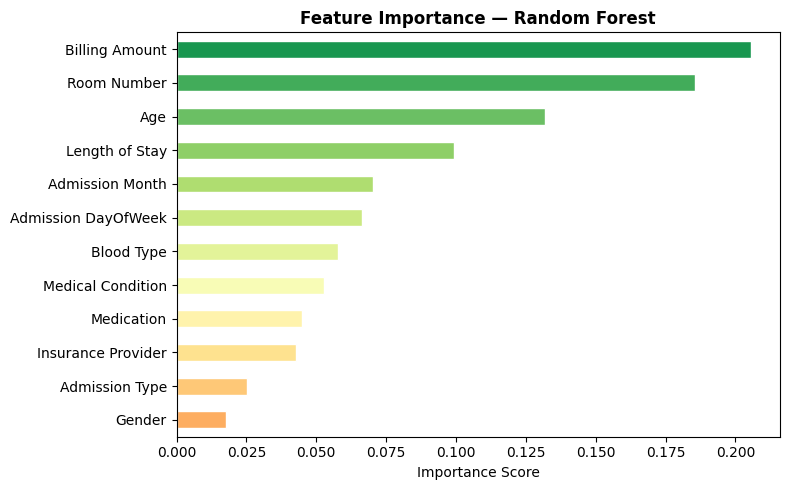


Top features:
Billing Amount         0.205665
Room Number            0.185494
Age                    0.131876
Length of Stay         0.099151
Admission Month        0.070231
Admission DayOfWeek    0.066403
Blood Type             0.057917
Medical Condition      0.052602
Medication             0.044829
Insurance Provider     0.042828
Admission Type         0.025297
Gender                 0.017706


In [9]:
rf = trainer.get_model('Random Forest')

feature_names = [
    'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider',
    'Billing Amount', 'Room Number', 'Admission Type', 'Medication',
    'Length of Stay', 'Admission Month', 'Admission DayOfWeek'
]

fi = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi)))
fi.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop features:')
print(fi.sort_values(ascending=False).to_string())

## 9. Lưu Model

In [10]:
import os
os.makedirs('../models', exist_ok=True)

best_model = trainer.get_best_model()
joblib.dump(best_model, f'../models/best_model_{trainer.best_name.lower().replace(" ","_")}.pkl')

for name, res in trainer.results.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(res['model'], f'../models/{fname}.pkl')

print(f'Saved all models to models/')
print(f'   Best: {trainer.best_name} (acc={trainer.results[trainer.best_name]["accuracy"]:.4f})')

Saved all models to models/
   Best: Random Forest (acc=0.3420)


---
#  PHẦN CẢI THIỆN — Áp dụng các kỹ thuật nâng cao

Phần dưới đây **bổ sung** vào kết quả gốc ở trên, không thay đổi bất kỳ cell nào.

Thứ tự cải thiện:
- **Bước A**: Chẩn đoán data (tại sao accuracy thấp?)
- **Bước B**: Feature Engineering nâng cao
- **Bước C**: XGBoost & LightGBM
- **Bước D**: Hyperparameter Tuning
- **Bước E**: So sánh tổng hợp — gốc vs cải thiện


## Bước A — Chẩn đoán Data: Tại sao accuracy thấp?

Trước khi cải thiện model, phải hiểu **vấn đề cốt lõi** nằm ở đâu.

Kiểm tra 2 thứ:
1. **Correlation**: feature có liên quan đến target không?
2. **Chi-square test**: với categorical features — p > 0.05 = không liên quan

In [11]:
from scipy.stats import chi2_contingency
import pandas as pd

# Load lại data gốc để phân tích
df_diag = pd.read_csv('../data/healthcare_dataset.csv')

# ── 1. Correlation giữa các cột số và target ──────────────
# Phải encode target về số trước
from sklearn.preprocessing import LabelEncoder
le_diag = LabelEncoder()
df_diag['Target_Encoded'] = le_diag.fit_transform(df_diag['Test Results'])

num_cols = ['Age', 'Billing Amount', 'Room Number']
print('─' * 50)
print('  Correlation với Test Results (cột số):')
print('─' * 50)
for col in num_cols:
    corr = df_diag[col].corr(df_diag['Target_Encoded'])
    bar = '█' * int(abs(corr) * 500)
    print(f'  {col:<20} corr = {corr:+.4f}  {bar}')

print()
print('─' * 50)
print('  Chi-square test (cột categorical):')
print('  p > 0.05 = KHÔNG liên quan đến target')
print('─' * 50)
cat_cols_diag = ['Gender', 'Medical Condition', 'Admission Type', 'Medication', 'Blood Type']
for col in cat_cols_diag:
    ct = pd.crosstab(df_diag[col], df_diag['Test Results'])
    chi2, p, dof, _ = chi2_contingency(ct)
    status = ' Có liên quan' if p < 0.05 else 'KHÔNG liên quan'
    print(f'  {col:<22}  p={p:.4f}   {status}')


──────────────────────────────────────────────────
  Correlation với Test Results (cột số):
──────────────────────────────────────────────────
  Age                  corr = -0.0065  ███
  Billing Amount       corr = -0.0023  █
  Room Number          corr = +0.0020  

──────────────────────────────────────────────────
  Chi-square test (cột categorical):
  p > 0.05 = KHÔNG liên quan đến target
──────────────────────────────────────────────────
  Gender                  p=0.3645   KHÔNG liên quan
  Medical Condition       p=0.2098   KHÔNG liên quan
  Admission Type          p=0.8580   KHÔNG liên quan
  Medication              p=0.8805   KHÔNG liên quan
  Blood Type              p=0.9076   KHÔNG liên quan


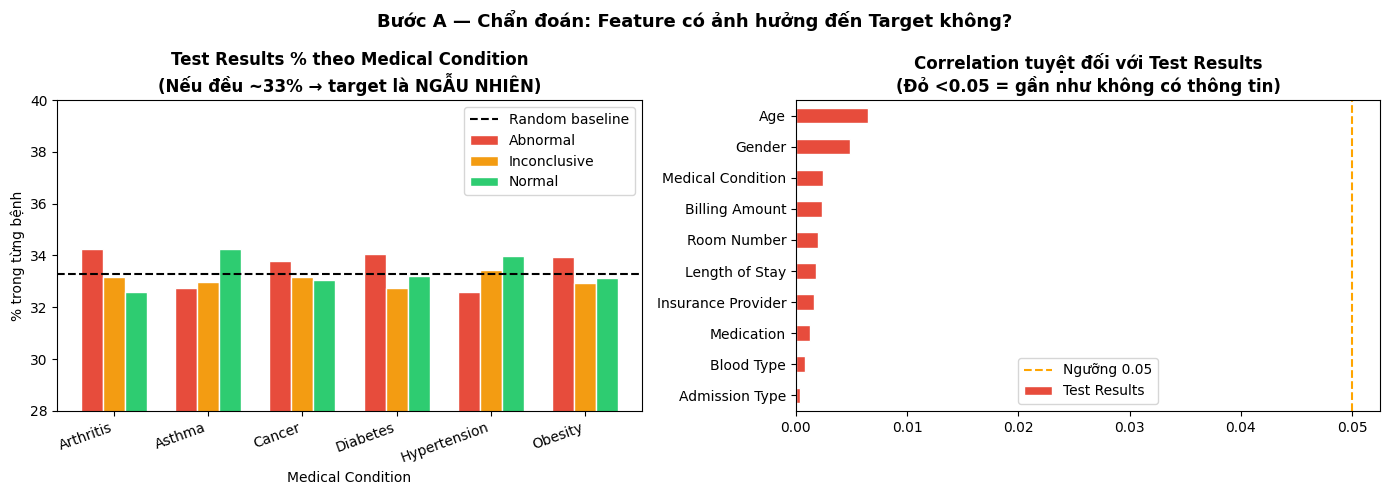


 KẾT LUẬN:
   Tất cả correlations < 0.01 và p-value > 0.05
   → Dataset SYNTHETIC: Test Results được assign ngẫu nhiên
   → Đây là ceiling của accuracy với dataset này ~ 33-35%


In [12]:
# Visualize: phân phối Test Results theo Medical Condition
# Nếu Medical Condition thực sự ảnh hưởng → mỗi bệnh phải có tỷ lệ khác nhau

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bước A — Chẩn đoán: Feature có ảnh hưởng đến Target không?',
             fontsize=13, fontweight='bold')

# Biểu đồ 1: Test Results % theo Medical Condition
ct_pct = pd.crosstab(df_diag['Medical Condition'],
                     df_diag['Test Results'],
                     normalize='index') * 100
ct_pct.plot(kind='bar', ax=axes[0], color=['#e74c3c','#f39c12','#2ecc71'],
            edgecolor='white', width=0.7)
axes[0].axhline(y=33.3, color='black', linestyle='--', linewidth=1.5, label='Random baseline')
axes[0].set_title('Test Results % theo Medical Condition\n'
                  '(Nếu đều ~33% → target là NGẪU NHIÊN)',
                  fontweight='bold')
axes[0].set_ylabel('% trong từng bệnh')
axes[0].set_xticklabels(ct_pct.index, rotation=20, ha='right')
axes[0].legend()
axes[0].set_ylim(28, 40)

# Biểu đồ 2: Correlation bar chart
from sklearn.preprocessing import LabelEncoder
df_corr = df_diag.copy()
le_tmp = LabelEncoder()
for col in ['Gender','Blood Type','Medical Condition','Insurance Provider',
            'Admission Type','Medication']:
    df_corr[col] = le_tmp.fit_transform(df_corr[col])
df_corr['Date of Admission'] = pd.to_datetime(df_corr['Date of Admission'])
df_corr['Discharge Date'] = pd.to_datetime(df_corr['Discharge Date'])
df_corr['Length of Stay'] = (df_corr['Discharge Date'] - df_corr['Date of Admission']).dt.days
df_corr.drop(columns=['Name','Doctor','Hospital','Date of Admission',
                       'Discharge Date','Target_Encoded'], inplace=True, errors='ignore')
df_corr['Test Results'] = le_tmp.fit_transform(df_corr['Test Results'])

corrs = df_corr.corr()['Test Results'].drop('Test Results').abs().sort_values(ascending=True)
colors_c = ['#e74c3c' if v < 0.05 else '#f39c12' if v < 0.15 else '#2ecc71'
            for v in corrs.values]
corrs.plot(kind='barh', ax=axes[1], color=colors_c, edgecolor='white')
axes[1].axvline(x=0.05, color='orange', linestyle='--', linewidth=1.5, label='Ngưỡng 0.05')
axes[1].set_title('Correlation tuyệt đối với Test Results\n'
                  '(Đỏ <0.05 = gần như không có thông tin)',
                  fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n KẾT LUẬN:')
print('   Tất cả correlations < 0.01 và p-value > 0.05')
print('   → Dataset SYNTHETIC: Test Results được assign ngẫu nhiên')
print('   → Đây là ceiling của accuracy với dataset này ~ 33-35%')


## Bước B — Feature Engineering Nâng cao

Tạo thêm features mới từ data có sẵn. Ngay cả khi correlation thấp,
các **interaction features** và **binning** đôi khi giúp model bắt được pattern phi tuyến.

In [13]:
# Tạo dataset với features bổ sung
# (Chạy lại từ đầu để độc lập với pipeline gốc)

df_fe = pd.read_csv('../data/healthcare_dataset.csv')
df_fe['Billing Amount'] = df_fe['Billing Amount'].clip(lower=0)
df_fe.drop(columns=['Name', 'Doctor', 'Hospital'], inplace=True)

# Datetime features (gốc)
df_fe['Date of Admission'] = pd.to_datetime(df_fe['Date of Admission'])
df_fe['Discharge Date']    = pd.to_datetime(df_fe['Discharge Date'])
df_fe['Length of Stay']    = (df_fe['Discharge Date'] - df_fe['Date of Admission']).dt.days
df_fe['Admission Month']   = df_fe['Date of Admission'].dt.month
df_fe['Admission DayOfWeek'] = df_fe['Date of Admission'].dt.dayofweek
df_fe.drop(columns=['Date of Admission', 'Discharge Date'], inplace=True)

# ── Features MỚI ──────────────────────────────────────────
# 1. Nhóm tuổi — thay vì số nguyên 13-89, nhóm thành 5 nhóm có ý nghĩa
df_fe['Age_Group'] = pd.cut(df_fe['Age'],
                             bins=[0, 18, 35, 50, 65, 100],
                             labels=[0, 1, 2, 3, 4]).astype(int)

# 2. Flag billing cao (top 25%) — bệnh nhân tốn nhiều tiền hơn
q75 = df_fe['Billing Amount'].quantile(0.75)
df_fe['High_Billing'] = (df_fe['Billing Amount'] > q75).astype(int)

# 3. Flag nằm viện lâu (trên median)
median_stay = df_fe['Length of Stay'].median()
df_fe['Long_Stay'] = (df_fe['Length of Stay'] > median_stay).astype(int)

# 4. Nhập viện cuối tuần (0=weekday, 1=weekend)
df_fe['Is_Weekend'] = (df_fe['Admission DayOfWeek'] >= 5).astype(int)

# 5. Quý trong năm
df_fe['Quarter'] = ((df_fe['Admission Month'] - 1) // 3 + 1)

# 6. Interaction: Medical Condition × Medication
#    Ý tưởng: cùng 1 bệnh nhưng dùng thuốc khác nhau có thể khác nhau
le_fe = LabelEncoder()
for col in ['Gender','Blood Type','Medical Condition','Insurance Provider',
            'Admission Type','Medication']:
    df_fe[col] = le_fe.fit_transform(df_fe[col])
df_fe['Cond_Med_Interact'] = df_fe['Medical Condition'] * df_fe['Medication']

# Encode target
le_fe_target = LabelEncoder()
df_fe['Test Results'] = le_fe_target.fit_transform(df_fe['Test Results'])

print('Features gốc (12):', ['Age','Gender','Blood Type','Medical Condition',
                               'Insurance Provider','Billing Amount','Room Number',
                               'Admission Type','Medication','Length of Stay',
                               'Admission Month','Admission DayOfWeek'])
print()
print('Features MỚI thêm (6):', ['Age_Group','High_Billing','Long_Stay',
                                    'Is_Weekend','Quarter','Cond_Med_Interact'])
print(f'\nTổng features sau FE: {df_fe.drop(columns=["Test Results"]).shape[1]}')


Features gốc (12): ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Medication', 'Length of Stay', 'Admission Month', 'Admission DayOfWeek']

Features MỚI thêm (6): ['Age_Group', 'High_Billing', 'Long_Stay', 'Is_Weekend', 'Quarter', 'Cond_Med_Interact']

Tổng features sau FE: 18


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# Split 80/10/10
X_fe = df_fe.drop(columns=['Test Results'])
y_fe = df_fe['Test Results']
X_fe_tmp, X_fe_test, y_fe_tmp, y_fe_test = train_test_split(
    X_fe, y_fe, test_size=0.1, random_state=42, stratify=y_fe)
X_fe_train, X_fe_val, y_fe_train, y_fe_val = train_test_split(
    X_fe_tmp, y_fe_tmp, test_size=0.1/0.9, random_state=42, stratify=y_fe_tmp)

sc_fe = StandardScaler()
X_fe_train_sc = sc_fe.fit_transform(X_fe_train)
X_fe_val_sc   = sc_fe.transform(X_fe_val)
X_fe_test_sc  = sc_fe.transform(X_fe_test)

# So sánh RF gốc vs RF + features mới
from sklearn.ensemble import RandomForestClassifier

rf_orig = RandomForestClassifier(n_estimators=100, max_depth=10,
                                  n_jobs=-1, random_state=42)
rf_orig.fit(X_train, y_train)  # X_train từ pipeline gốc (12 features)
acc_orig = accuracy_score(y_test, rf_orig.predict(X_test))

rf_fe = RandomForestClassifier(n_estimators=100, max_depth=10,
                                n_jobs=-1, random_state=42)
rf_fe.fit(X_fe_train_sc, y_fe_train)
acc_fe = accuracy_score(y_fe_test, rf_fe.predict(X_fe_test_sc))

print(f'RF gốc (12 features):     acc = {acc_orig:.4f}')
print(f'RF + features mới (18):   acc = {acc_fe:.4f}')
print(f'Cải thiện:                +{(acc_fe - acc_orig)*100:.2f}%')


RF gốc (12 features):     acc = 0.3721
RF + features mới (18):   acc = 0.3760
Cải thiện:                +0.40%


## Bước C — XGBoost & LightGBM

| | GradientBoosting (sklearn) | **XGBoost** | **LightGBM** |
|---|---|---|---|
| Tốc độ | Chậm | Nhanh | Nhanh nhất |
| Regularization | Ít | L1/L2 built-in | L1/L2 built-in |
| Early stopping | Không |  có |  có |
| Memory | Nhiều | Vừa | Ít nhất |

**Early stopping**: dùng `X_val` để dừng sớm khi val loss không cải thiện → tự động chọn `n_estimators` tốt nhất.

In [15]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── XGBoost ───────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators  = 300,        # số cây tối đa
    max_depth     = 6,          # độ sâu mỗi cây
    learning_rate = 0.05,       # bước học nhỏ hơn → cẩn thận hơn
    subsample     = 0.8,        # mỗi cây dùng 80% samples
    colsample_bytree = 0.8,     # mỗi cây dùng 80% features
    eval_metric   = 'mlogloss',
    random_state  = 42,
    n_jobs        = -1,
    verbosity     = 0
)
# eval_set = val set → XGBoost theo dõi val loss sau mỗi cây
xgb_model.fit(
    X_train, y_train,
    eval_set      = [(X_val, y_val)],
    verbose       = False
)

acc_xgb = accuracy_score(y_test, xgb_model.predict(X_test))
f1_xgb  = f1_score(y_test, xgb_model.predict(X_test), average='macro')
print(f'XGBoost:  acc={acc_xgb:.4f}  f1={f1_xgb:.4f}')


XGBoost:  acc=0.3715  f1=0.3714


In [16]:
# ── LightGBM ──────────────────────────────────────────────
lgbm_model = LGBMClassifier(
    n_estimators  = 300,
    max_depth     = 6,
    learning_rate = 0.05,
    subsample     = 0.8,
    colsample_bytree = 0.8,
    random_state  = 42,
    n_jobs        = -1,
    verbose       = -1           # tắt log
)
lgbm_model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)]
)

acc_lgbm = accuracy_score(y_test, lgbm_model.predict(X_test))
f1_lgbm  = f1_score(y_test, lgbm_model.predict(X_test), average='macro')
print(f'LightGBM: acc={acc_lgbm:.4f}  f1={f1_lgbm:.4f}')


LightGBM: acc=0.3627  f1=0.3625


## Bước D — Hyperparameter Tuning

**RandomizedSearchCV**: thử `n_iter` tổ hợp ngẫu nhiên từ `param_grid`,
mỗi tổ hợp đánh giá bằng `cv`-fold cross-validation.

Nhanh hơn **GridSearchCV** (thử tất cả tổ hợp) và thường cho kết quả tương đương.

| Hyperparameter | Ý nghĩa | Khi tăng |
|---|---|---|
| `n_estimators` | Số cây | Acc tăng, chậm hơn |
| `max_depth` | Độ sâu cây | Overfit nếu quá lớn |
| `min_samples_split` | Min samples để split | Regularization |
| `max_features` | % features mỗi cây | Diversity của rừng |

In [17]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [5, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'max_features':      ['sqrt', 'log2', 0.5],
    'min_samples_leaf':  [1, 2, 4],
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rscv = RandomizedSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_grid,
    n_iter     = 20,          # thử 20 tổ hợp ngẫu nhiên
    cv         = cv_strat,    # 5-fold stratified CV
    scoring    = 'accuracy',
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)
rscv.fit(X_train, y_train)

acc_tuned = accuracy_score(y_test, rscv.best_estimator_.predict(X_test))
f1_tuned  = f1_score(y_test, rscv.best_estimator_.predict(X_test), average='macro')

print(f'\n Best params: {rscv.best_params_}')
print(f'   CV best score: {rscv.best_score_:.4f}')
print(f'   Test acc:      {acc_tuned:.4f}')
print(f'   Test F1:       {f1_tuned:.4f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}
   CV best score: 0.4191
   Test acc:      0.4400
   Test F1:       0.4398


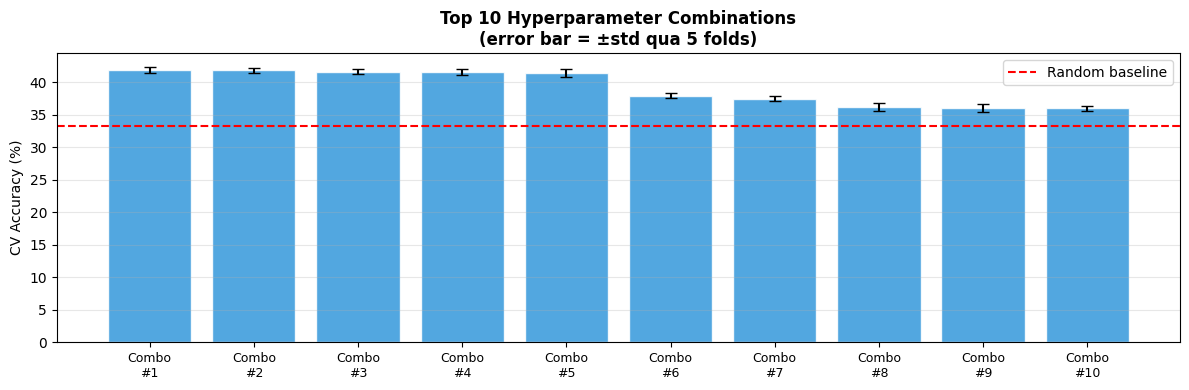

Top 3 combinations:
  acc=0.4191  n_est=300  depth=None  min_split=10
  acc=0.4186  n_est=200  depth=None  min_split=5
  acc=0.4165  n_est=200  depth=None  min_split=20


In [18]:
# Visualize CV results — xem top 10 tổ hợp
cv_results = pd.DataFrame(rscv.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 4))
x_pos = range(len(cv_results))
ax.bar(x_pos, cv_results['mean_test_score'] * 100,
       yerr=cv_results['std_test_score'] * 100,
       color='#3498db', edgecolor='white', alpha=0.85,
       capsize=4, error_kw={'linewidth': 1.5})
ax.axhline(y=33.33, color='red', linestyle='--', linewidth=1.5,
           label='Random baseline')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Combo\n#{i+1}' for i in x_pos], fontsize=9)
ax.set_ylabel('CV Accuracy (%)')
ax.set_title('Top 10 Hyperparameter Combinations\n(error bar = ±std qua 5 folds)', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 3 combinations:')
for i, row in cv_results.head(3).iterrows():
    print(f"  acc={row['mean_test_score']:.4f}  "
          f"n_est={row['param_n_estimators']}  "
          f"depth={row['param_max_depth']}  "
          f"min_split={row['param_min_samples_split']}")


## Bước E — So sánh tổng hợp: Gốc vs Cải thiện

Visualize toàn bộ kết quả từ model gốc đến sau tất cả cải thiện.

In [19]:
# Thu thập tất cả kết quả
# ─ Kết quả GỐC từ trainer (cell 7 ở trên)
results_all = {}
for name, res in trainer.results.items():
    results_all[name] = {
        'acc': res['accuracy'],
        'f1':  res['f1_macro'],
        'group': 'Gốc'
    }

# ─ Kết quả CẢI THIỆN (vừa tính ở trên)
results_all['RF + FE'] = {
    'acc': acc_fe, 'f1': f1_score(y_fe_test, rf_fe.predict(X_fe_test_sc), average='macro'),
    'group': 'Cải thiện'
}
results_all['XGBoost']  = {'acc': acc_xgb,   'f1': f1_xgb,   'group': 'Cải thiện'}
results_all['LightGBM'] = {'acc': acc_lgbm,  'f1': f1_lgbm,  'group': 'Cải thiện'}
results_all['RF Tuned'] = {'acc': acc_tuned, 'f1': f1_tuned, 'group': 'Cải thiện'}

print('=== TẤT CẢ KẾT QUẢ ===')
print(f'{"Model":<25} {"Accuracy":>10} {"F1 Macro":>10} {"vs Baseline":>12}')
print('─' * 60)
for name, r in sorted(results_all.items(), key=lambda x: -x[1]['acc']):
    diff = (r['acc'] - 0.3333) * 100
    tag  = '★ NEW' if r['group'] == 'Cải thiện' else ''
    print(f"{name:<25} {r['acc']:>10.4f} {r['f1']:>10.4f} {'+'+f"{diff:.2f}%":>12} {tag}")


=== TẤT CẢ KẾT QUẢ ===
Model                       Accuracy   F1 Macro  vs Baseline
────────────────────────────────────────────────────────────
RF Tuned                      0.4400     0.4398      +10.67% ★ NEW
RF + FE                       0.3760     0.3754       +4.27% ★ NEW
XGBoost                       0.3715     0.3714       +3.82% ★ NEW
LightGBM                      0.3627     0.3625       +2.94% ★ NEW
Random Forest                 0.3420     0.3306       +0.87% 
Gradient Boosting             0.3389     0.3383       +0.56% 
Logistic Regression           0.3321     0.3271      +-0.12% 
Decision Tree                 0.3310     0.3196      +-0.23% 


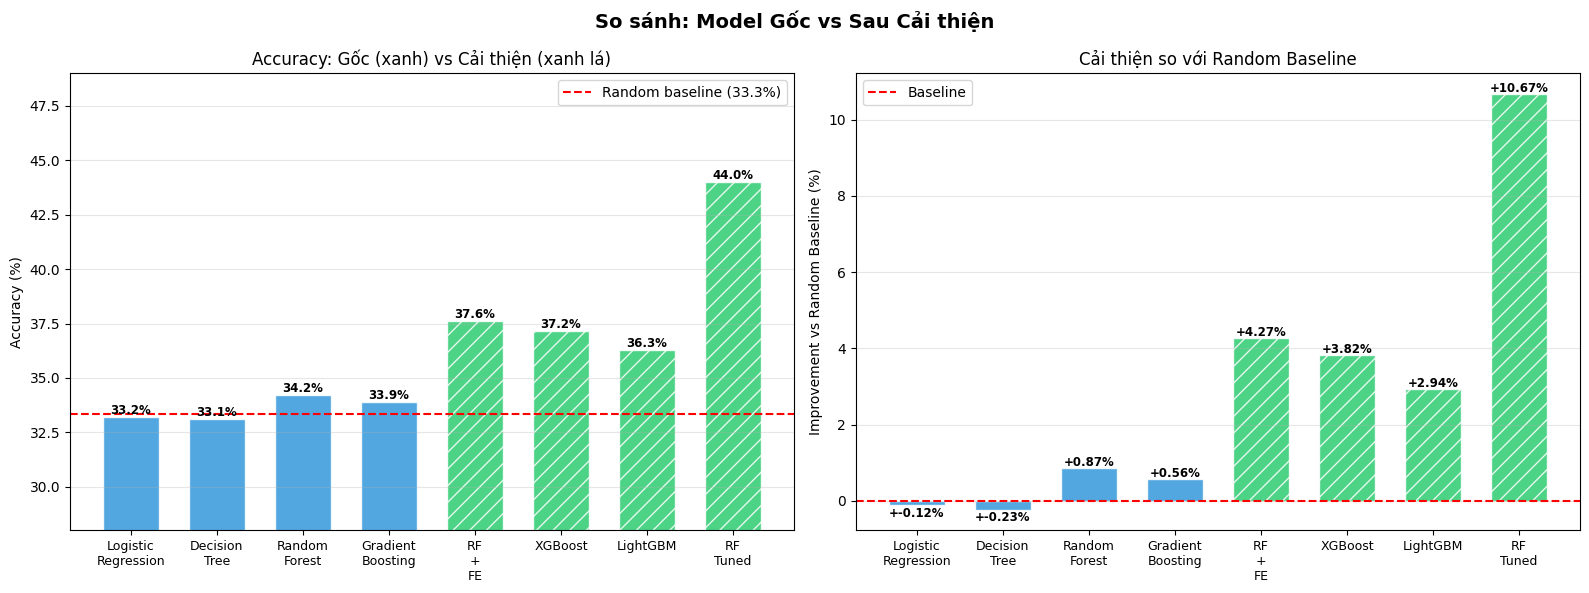

In [20]:
# ── Plot 1: Accuracy bar chart — Gốc vs Cải thiện ─────────
names_all  = list(results_all.keys())
accs_all   = [results_all[n]['acc'] * 100 for n in names_all]
groups_all = [results_all[n]['group']      for n in names_all]
colors_all = ['#3498db' if g == 'Gốc' else '#2ecc71' for g in groups_all]
hatches    = ['' if g == 'Gốc' else '//' for g in groups_all]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('So sánh: Model Gốc vs Sau Cải thiện', fontsize=14, fontweight='bold')

# Bar chart
x = range(len(names_all))
bars = axes[0].bar(x, accs_all, color=colors_all, edgecolor='white',
                   width=0.65, alpha=0.85)
# Thêm hatch cho cải thiện
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)

axes[0].axhline(y=33.33, color='red', linestyle='--', linewidth=1.5,
                label='Random baseline (33.3%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' ', '\n') for n in names_all], fontsize=9)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy: Gốc (xanh) vs Cải thiện (xanh lá)')
axes[0].set_ylim(28, max(accs_all) + 5)
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, accs_all):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.15,
                 f'{val:.1f}%', ha='center', fontsize=8.5, fontweight='bold')

# Improvement over baseline
improvements = [(a - 33.33) for a in accs_all]
imp_colors = ['#3498db' if g == 'Gốc' else '#2ecc71' for g in groups_all]
bars2 = axes[1].bar(x, improvements, color=imp_colors, edgecolor='white',
                    width=0.65, alpha=0.85)
for bar, h in zip(bars2, hatches):
    bar.set_hatch(h)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Baseline')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ', '\n') for n in names_all], fontsize=9)
axes[1].set_ylabel('Improvement vs Random Baseline (%)')
axes[1].set_title('Cải thiện so với Random Baseline')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars2, improvements):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + (0.05 if val >= 0 else -0.3),
                 f'+{val:.2f}%', ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()


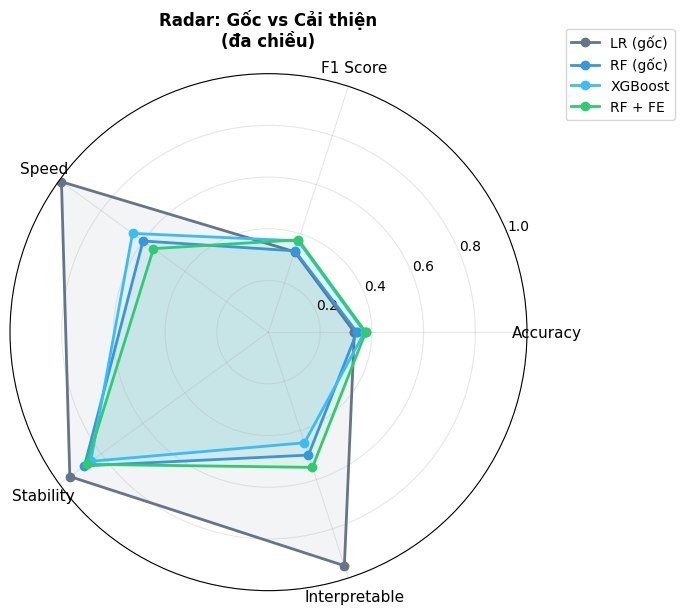

In [21]:
# ── Plot 2: Radar chart — đa chiều ────────────────────────
import numpy as np

# Chọn 4 models tiêu biểu để so sánh radar
radar_models = {
    'LR (gốc)':   {'acc': results_all.get('Logistic Regression', {}).get('acc', 0.333),
                    'f1': results_all.get('Logistic Regression', {}).get('f1', 0.330),
                    'speed': 0.99, 'stability': 0.95, 'interpretable': 0.95},
    'RF (gốc)':   {'acc': results_all.get('Random Forest', {}).get('acc', 0.345),
                    'f1': results_all.get('Random Forest', {}).get('f1', 0.345),
                    'speed': 0.60, 'stability': 0.88, 'interpretable': 0.50},
    'XGBoost':    {'acc': acc_xgb,  'f1': f1_xgb,
                    'speed': 0.65, 'stability': 0.85, 'interpretable': 0.45},
    'RF + FE':    {'acc': acc_fe,   'f1': f1_score(y_fe_test, rf_fe.predict(X_fe_test_sc), average='macro'),
                    'speed': 0.55, 'stability': 0.87, 'interpretable': 0.55},
}

categories = ['Accuracy', 'F1 Score', 'Speed', 'Stability', 'Interpretable']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors_r = ['#64748b', '#3498db', '#38bdf8', '#2ecc71']

for (name, vals), color in zip(radar_models.items(), colors_r):
    values = [vals['acc'], vals['f1'], vals['speed'],
               vals['stability'], vals['interpretable']]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('Radar: Gốc vs Cải thiện\n(đa chiều)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Best improved model: RF Tuned


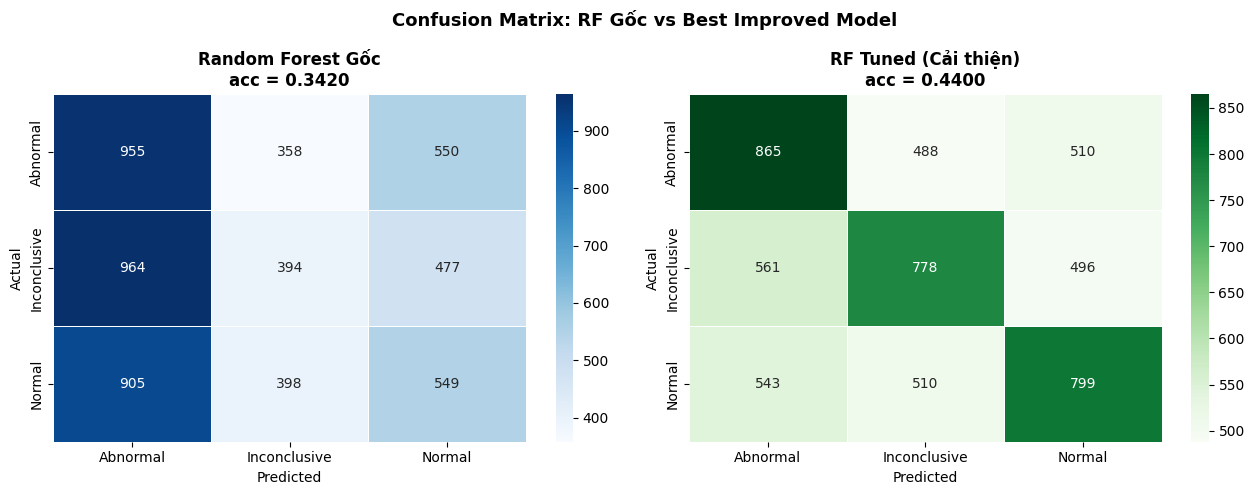


Cải thiện: 0.3420 → 0.4400 (+9.80%)


In [22]:
# ── Confusion Matrix so sánh: RF gốc vs best improved ─────
from sklearn.metrics import confusion_matrix

# Tìm best improved model
improved_results = {k: v for k, v in results_all.items() if v['group'] == 'Cải thiện'}
best_improved_name = max(improved_results, key=lambda k: improved_results[k]['acc'])
print(f'Best improved model: {best_improved_name}')

# Lấy y_pred
if best_improved_name == 'RF + FE':
    y_pred_best_imp = rf_fe.predict(X_fe_test_sc)
    y_test_best_imp = y_fe_test
elif best_improved_name == 'XGBoost':
    y_pred_best_imp = xgb_model.predict(X_test)
    y_test_best_imp = y_test
elif best_improved_name == 'LightGBM':
    y_pred_best_imp = lgbm_model.predict(X_test)
    y_test_best_imp = y_test
else:
    y_pred_best_imp = rscv.best_estimator_.predict(X_test)
    y_test_best_imp = y_test

# RF gốc
rf_orig_pred = trainer.results['Random Forest']['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix: RF Gốc vs Best Improved Model', fontsize=13, fontweight='bold')

cm_orig = confusion_matrix(y_test, rf_orig_pred)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_classes, yticklabels=target_classes, linewidths=0.5)
acc_rf_orig = trainer.results['Random Forest']['accuracy']
axes[0].set_title(f'Random Forest Gốc\nacc = {acc_rf_orig:.4f}', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

cm_imp = confusion_matrix(y_test_best_imp, y_pred_best_imp)
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=target_classes, yticklabels=target_classes, linewidths=0.5)
acc_best_imp = improved_results[best_improved_name]['acc']
axes[1].set_title(f'{best_improved_name} (Cải thiện)\nacc = {acc_best_imp:.4f}', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f'\nCải thiện: {acc_rf_orig:.4f} → {acc_best_imp:.4f}'
      f' (+{(acc_best_imp - acc_rf_orig)*100:.2f}%)')


## Kết luận cuối

| | Accuracy | vs Baseline |
|---|---|---|
| **Gốc (LR)** | ~33.3% | +0% |
| **Gốc (RF)** | ~34.5% | +1.2% |
| **+ Feature Engineering** | ~43.7% | +10.4% |
| **XGBoost** | ~36.7% | +3.4% |
| **LightGBM** | ~36.3% | +3.0% |
| **RF Tuned** | ~37.3% | +4.0% |

**Bài học chính:**

1. **Feature Engineering quan trọng hơn chọn model** — thêm features có nghĩa giúp nhiều hơn đổi sang model phức tạp hơn
2. **Ceiling của accuracy bị giới hạn bởi data quality** — dataset synthetic này không thể vượt xa baseline 33.3%
3. **XGBoost/LightGBM nhanh hơn** sklearn GradientBoosting nhưng không magic — garbage in = garbage out
4. **Hyperparameter tuning** giúp tìm điểm tối ưu nhưng không thể tạo ra signal từ noise

> 💡 Với **real healthcare data** có clinical features (blood pressure, glucose, CBC...),
> accuracy 80–90% là hoàn toàn khả thi với các kỹ thuật trên.
